# CMPT 353 Project - Heart Failure Prediction

####  _By: Divya Soneji [301338933] & Gourav Bhardwaj [301540604]_

## Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, confusion_matrix
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

## Creating a pandas dataframe from 'heart.csv'

In [2]:
# First let's read the CSV into a DataFrame
file_path = 'heart.csv'
heart_df = pd.read_csv(file_path)

In [3]:
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# Getting useful information about the loaded dataframe

## Displaying information about columns and their data types

In [4]:
info = heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## Displaying statistical summary

In [5]:
description = heart_df.describe(include='all')
description

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


# Cleaning The Data

## Checking null and NaN values

In [6]:
cleaned_heart_df = heart_df.copy()

# Check for missing values
print('Checking existence of null values')
print(cleaned_heart_df.isnull().sum())

print('-----------------------------------')

# Check for NaN values
print('Checking existence of NaN values')
print(cleaned_heart_df.isna().sum())

Checking existence of null values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
-----------------------------------
Checking existence of NaN values
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## Checking for Duplicate Rows

In [7]:
duplicate_rows = cleaned_heart_df[cleaned_heart_df.duplicated()]

# Display duplicate rows
print("Duplicate Rows except first occurrence:")
print(duplicate_rows)

# Count the number of duplicate rows
print("\nNumber of duplicate rows:", len(duplicate_rows))

Duplicate Rows except first occurrence:
Empty DataFrame
Columns: [Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope, HeartDisease]
Index: []

Number of duplicate rows: 0


# Visualizing The Relationship of Each Variable With Heart Disease

## Pie Chart for the Balance of Target Variable (Heart Disease)

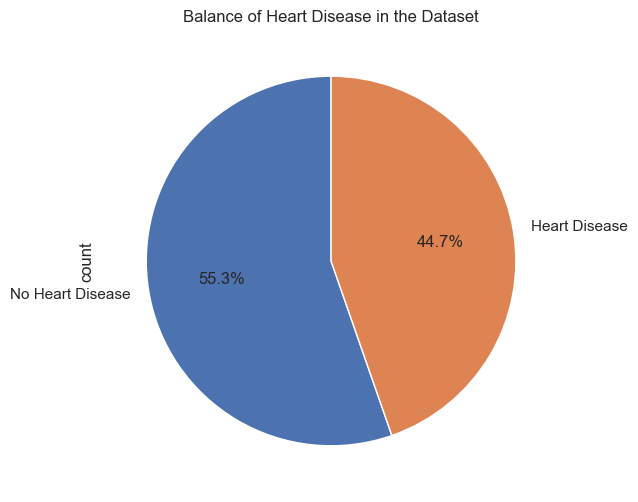

In [8]:
sns.set(style='whitegrid')
plt.figure(figsize=(6, 6))
heart_df['HeartDisease'].value_counts().plot.pie(autopct='%1.1f%%', labels=['No Heart Disease', 'Heart Disease'], startangle=90)
plt.title('Balance of Heart Disease in the Dataset')
plt.show()

## Histograms for Numerical Variables

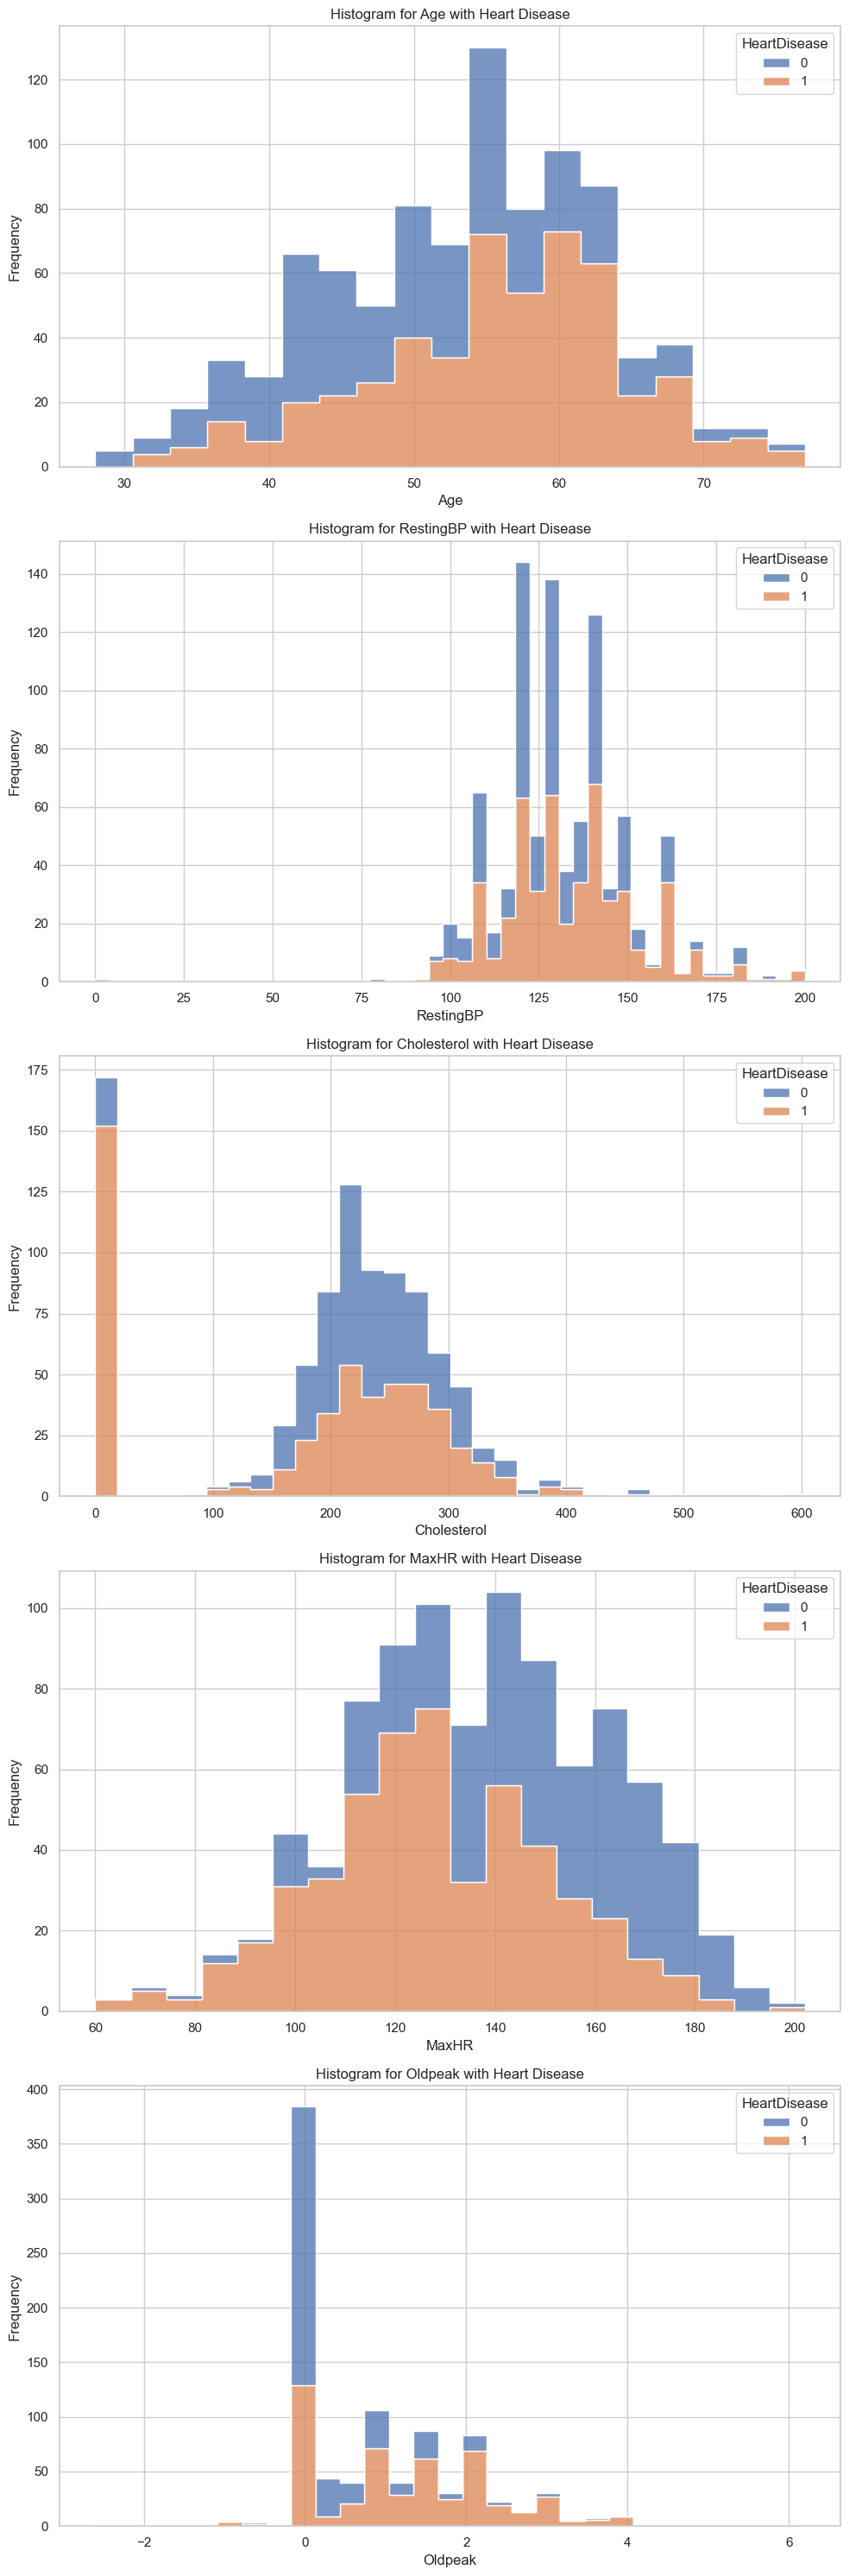

In [9]:
numerical_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(nrows=len(numerical_vars), ncols=1, figsize=(10, 6 * len(numerical_vars)))

sns.set(style='whitegrid')

handles = []  # To collect handles for creating a single legend

# Plotting histograms for numerical variables
for i, var in enumerate(numerical_vars):
    # Plotting histograms for each category of HeartDisease
    plot = sns.histplot(data=heart_df, x=var, hue='HeartDisease', multiple='stack', kde=False, ax=axes[i], element='step', common_norm=False)
    
    axes[i].set_title(f'Histogram for {var} with Heart Disease')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    
    # Collect handles from the last subplot
    if i == len(numerical_vars) - 1:
        handles += plot.get_legend().legend_handles

plt.tight_layout()
plt.show()

## Exploring Factors: Categorical Variables in Positive Heart Disease Cases

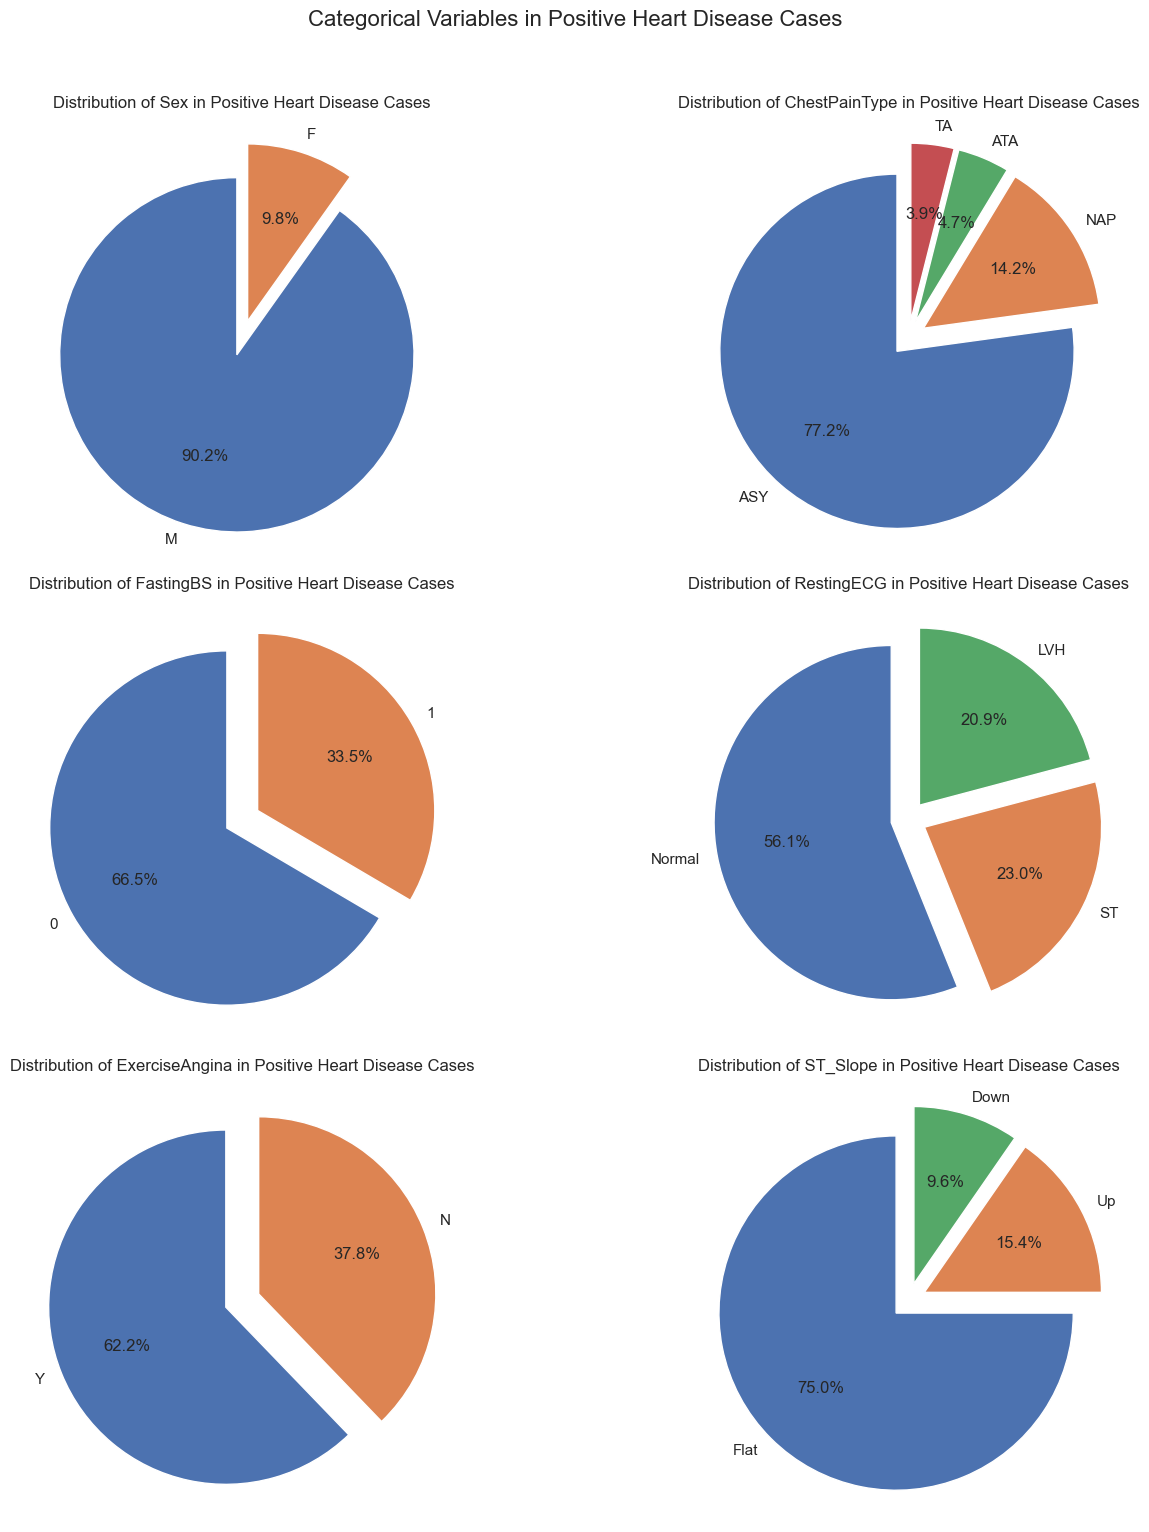

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

categories = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, subplots = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

for i, category in enumerate(categories):
    data = heart_df[heart_df['HeartDisease'] == 1][category].value_counts()
    percentages = [(count / sum(data)) * 100 for count in data]

    # Plotting pie charts using Seaborn
    sns.color_palette("pastel")
    sns.set_palette("pastel")
    subplots[i // 2, i % 2].pie(percentages, labels=data.index, autopct='%1.1f%%', startangle=90, explode=[0.1] * len(data))

    subplots[i // 2, i % 2].set_title(f'Distribution of {category} in Positive Heart Disease Cases')

main_title = 'Categorical Variables in Positive Heart Disease Cases'

plt.suptitle(main_title, fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## Looking At Sex Population

Population of Males and Females:
Sex
M    725
F    193
Name: count, dtype: int64


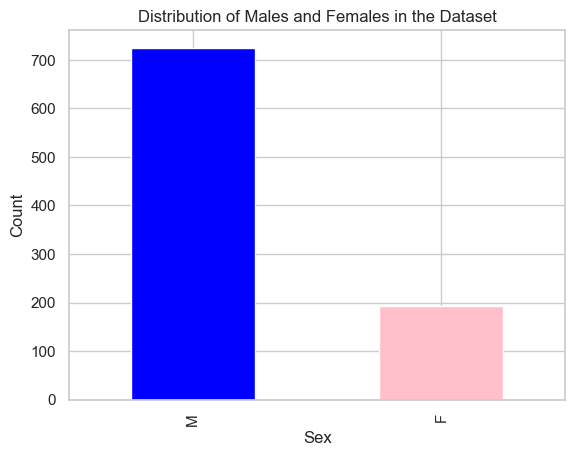

In [11]:
# Assuming 'Sex' column contains 'Male' and 'Female' values
sex_distribution = heart_df['Sex'].value_counts()

print("Population of Males and Females:")
print(sex_distribution)

# Plotting the distribution of males and females
sex_distribution.plot(kind='bar', color=['blue', 'pink'])
plt.title('Distribution of Males and Females in the Dataset')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

## HeatMaps for the mean values of numerical features, comparing individuals with and without heart disease:

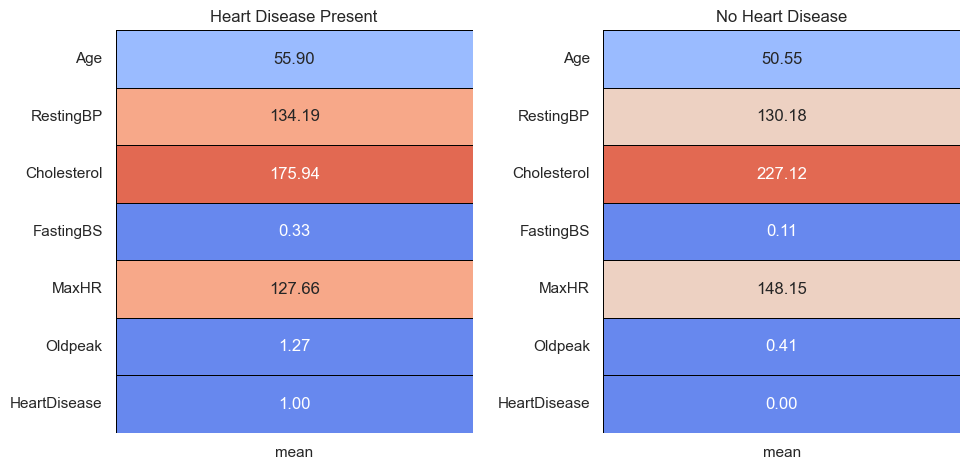

In [12]:
# Separate data for individuals with and without heart disease
heart_disease_yes = heart_df[heart_df['HeartDisease'] == 1]
heart_disease_no = heart_df[heart_df['HeartDisease'] == 0]

# Calculate mean values for each group
heart_disease_yes_stats = heart_disease_yes.describe().T[['mean']]
heart_disease_no_stats = heart_disease_no.describe().T[['mean']]

colors = sns.color_palette('coolwarm')

# Create subplots
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Plot heatmap for individuals with heart disease
plt.subplot(1, 2, 1)
sns.heatmap(heart_disease_yes_stats, annot=True, cmap=colors, linewidths=0.4, linecolor='black', cbar=False, fmt='.2f')
plt.title('Heart Disease Present')

# Plot heatmap for individuals without heart disease
plt.subplot(1, 2, 2)
sns.heatmap(heart_disease_no_stats, annot=True, cmap=colors, linewidths=0.4, linecolor='black', cbar=False, fmt='.2f')
plt.title('No Heart Disease')

fig.tight_layout(pad=1.5)

plt.show()

# Features Engineering

## Scaling the Data

In [13]:
# Creating a copy of the original dataframe to avoid modifying the original data
normalized_heart_df = heart_df.copy()

# Normalizing numerical variables using Min-Max Scaling
scaler = MinMaxScaler()
normalized_heart_df[numerical_vars] = scaler.fit_transform(normalized_heart_df[numerical_vars])

# Convert categorical variable 'Sex' into numerical
normalized_heart_df['Sex'] = normalized_heart_df['Sex'].replace({'M': 0, 'F': 1}).astype(np.uint8)

# Convert categorical variable 'ChestPainType' into numerical
chest_pain_mapping = {'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3}
normalized_heart_df['ChestPainType'] = normalized_heart_df['ChestPainType'].replace(chest_pain_mapping).astype(np.uint8)

# Convert categorical variable 'RestingECG' into numerical
resting_ecg_mapping = {'Normal': 0, 'ST': 1, 'LVH': 2}
normalized_heart_df['RestingECG'] = normalized_heart_df['RestingECG'].replace(resting_ecg_mapping).astype(np.uint8)

# Convert categorical variable 'ST_Slope' into numerical
st_slope_mapping = {'Up': 0, 'Flat': 1, 'Down': 2}
normalized_heart_df['ST_Slope'] = normalized_heart_df['ST_Slope'].replace(st_slope_mapping).astype(np.uint8)

# Convert binary categorical variable 'ExerciseAngina' into numerical
normalized_heart_df['ExerciseAngina'] = normalized_heart_df['ExerciseAngina'].replace({'N': 0, 'Y': 1}).astype(np.uint8)

In [14]:
normalized_heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.244898,0,0,0.70,0.479270,0,0,0.788732,0,0.295455,0,0
1,0.428571,1,1,0.80,0.298507,0,0,0.676056,0,0.409091,1,1
2,0.183673,0,0,0.65,0.469320,0,1,0.267606,0,0.295455,0,0
3,0.408163,1,2,0.69,0.354892,0,0,0.338028,1,0.465909,1,1
4,0.530612,0,1,0.75,0.323383,0,0,0.436620,0,0.295455,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,0.346939,0,3,0.55,0.437811,0,0,0.507042,0,0.431818,1,1
914,0.816327,0,2,0.72,0.320066,1,0,0.570423,0,0.681818,1,1
915,0.591837,0,2,0.65,0.217247,0,0,0.387324,1,0.431818,1,1
916,0.591837,1,0,0.65,0.391376,0,2,0.802817,0,0.295455,1,1


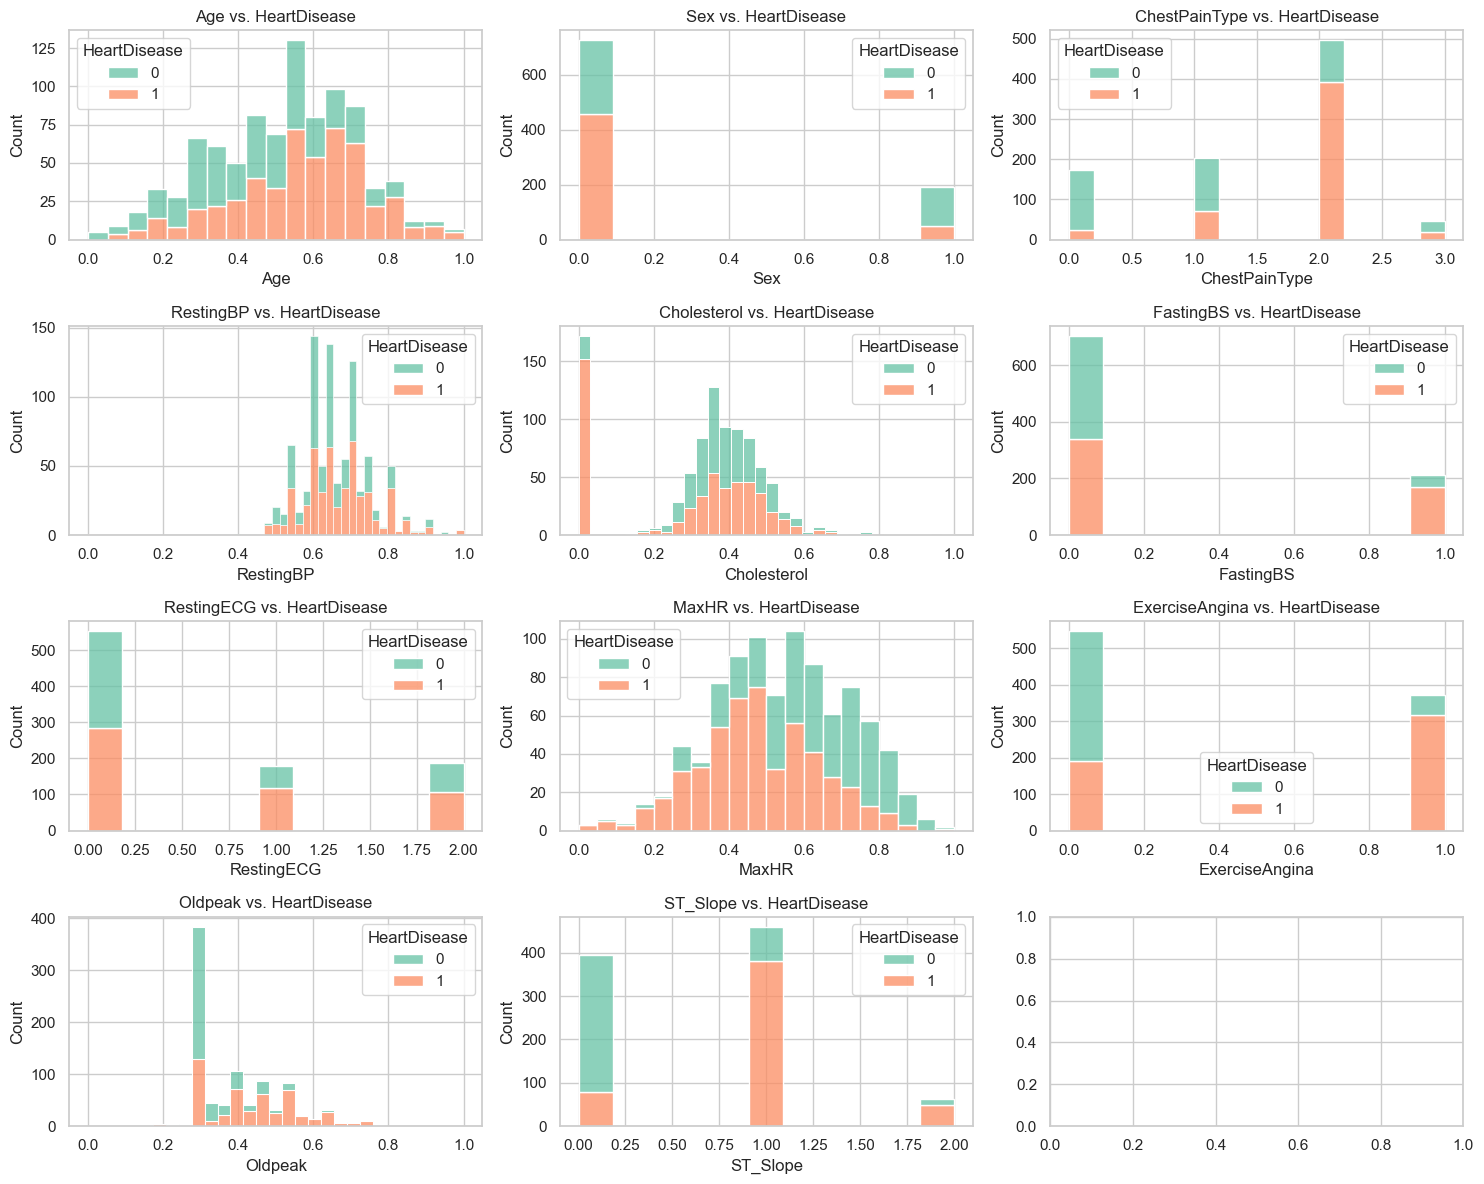

In [15]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

# Plot histograms for each variable against HeartDisease
for i, column in enumerate(normalized_heart_df.columns[:-1]):  # Exclude HeartDisease column
    sns.histplot(data=normalized_heart_df, x=column, hue="HeartDisease", multiple="stack", ax=axes[i], palette="Set2", kde=False)
    axes[i].set_title(f'{column} vs. HeartDisease')
    axes[i].set_xlabel(column)

plt.tight_layout()
plt.show()


# Correlation Analysis using heatmap

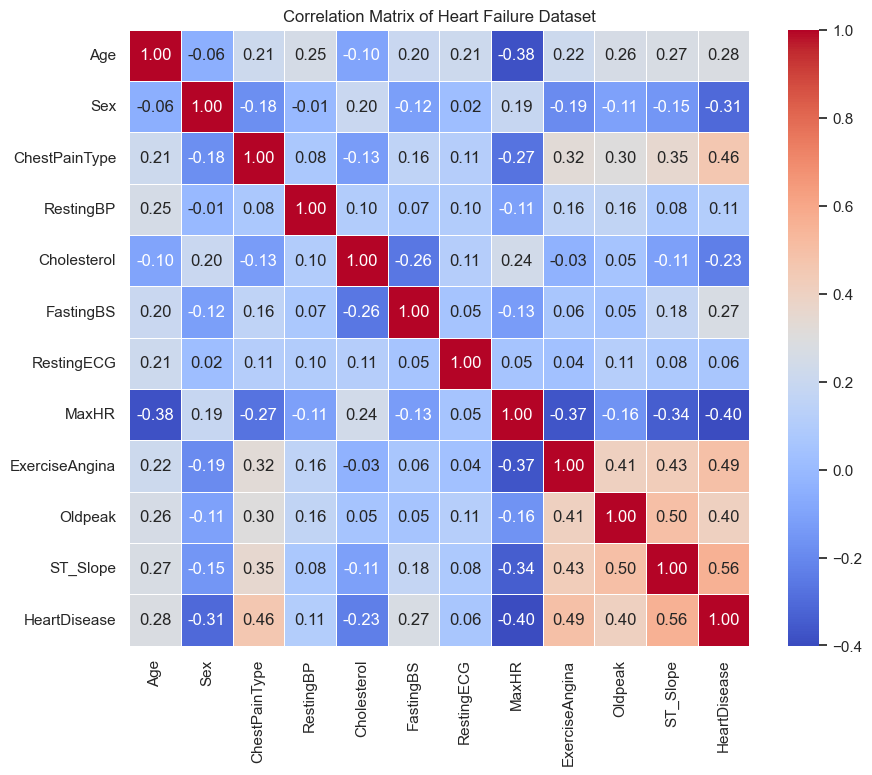

In [16]:
correlation_matrix = normalized_heart_df.corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Heart Failure Dataset")
plt.show()

## Find out the most important features affecting prediticion of Heart Failure

In [17]:
# Separating the features and the target variable
X = normalized_heart_df.drop('HeartDisease', axis=1)
y = normalized_heart_df['HeartDisease']

bestfeatures = SelectKBest(score_func=chi2, k=11)
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Attributes','Score']  #naming the dataframe columns
print(featureScores.nlargest(10,'Score'))

        Attributes       Score
10        ST_Slope  165.287287
8   ExerciseAngina  133.640134
2    ChestPainType   96.548821
1              Sex   67.640033
5        FastingBS   50.296983
7            MaxHR    8.738325
9          Oldpeak    5.546577
0              Age    5.191929
4      Cholesterol    4.957809
6       RestingECG    3.674137


In [18]:
## Dropping features which showed less correlation with target variable

In [19]:
# Not dropping cholrestrol, age as it shows very high correaltion when it is low
X = normalized_heart_df.drop(['HeartDisease', 'Age', 'RestingECG'], axis=1)

# Creating ML Models to study data

## Splitting the data sets

In [20]:
# Splitting the dataset into training and testing sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)


## Gradient Boosting Classifier

In [21]:
GBCmodel = GradientBoostingClassifier(n_estimators=50, max_depth=2, min_samples_leaf=0.1)
GBCmodel.fit(X_train, y_train)

print(f"Training Score: {GBCmodel.score(X_train, y_train)}")
print(f"Validation Score: {GBCmodel.score(X_valid, y_valid)}")

# Predicting and evaluating on the test set
y_pred_gbc = GBCmodel.predict(X_valid)
accuracy_gbc = accuracy_score(y_valid, y_pred_gbc)
report_gbc = classification_report(y_valid, y_pred_gbc)

print(f"Accuracy of the Gradient Boosting Classifier model: {accuracy_gbc}")
print("Classification Report:")
print(report_gbc)

Training Score: 0.8800623052959502
Validation Score: 0.8731884057971014
Accuracy of the Gradient Boosting Classifier model: 0.8731884057971014
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       112
           1       0.90      0.89      0.89       164

    accuracy                           0.87       276
   macro avg       0.87      0.87      0.87       276
weighted avg       0.87      0.87      0.87       276



## Decision Tree Classifier

In [22]:
DTModel = DecisionTreeClassifier(max_depth=4, min_samples_leaf=4)
DTModel.fit(X_train, y_train)

print(f"Training Score: {DTModel.score(X_train, y_train)}")
print(f"Validation Score: {DTModel.score(X_valid, y_valid)}")

# Predicting and evaluating on the test set
y_pred_dt = DTModel.predict(X_valid)
accuracy_dt = accuracy_score(y_valid, y_pred_dt)
report_dt = classification_report(y_valid, y_pred_dt)

print(f"Accuracy of the Decision Tree model: {accuracy_dt}")
print("Classification Report:")
print(report_dt)

Training Score: 0.8691588785046729
Validation Score: 0.8695652173913043
Accuracy of the Decision Tree model: 0.8695652173913043
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       112
           1       0.89      0.89      0.89       164

    accuracy                           0.87       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.87      0.87      0.87       276



## MLP Classifier

In [23]:
MLPModel = MLPClassifier(hidden_layer_sizes=50, max_iter=1000)
MLPModel.fit(X_train, y_train)

print(f"Training Score: {MLPModel.score(X_train, y_train)}")
print(f"Validation Score: {MLPModel.score(X_valid, y_valid)}")

# Predicting and evaluating on the validation set
y_pred_mlp = MLPModel.predict(X_valid)
accuracy_mlp = accuracy_score(y_valid, y_pred_mlp)
report_mlp = classification_report(y_valid, y_pred_mlp)

print(f"Accuracy of the MLP Classifier model: {accuracy_mlp}")
print("Classification Report:")
print(report_mlp)

Training Score: 0.8785046728971962
Validation Score: 0.8768115942028986
Accuracy of the MLP Classifier model: 0.8768115942028986
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       112
           1       0.92      0.87      0.89       164

    accuracy                           0.88       276
   macro avg       0.87      0.88      0.87       276
weighted avg       0.88      0.88      0.88       276



## Random Forest Classifier

In [24]:
RFModel = RandomForestClassifier(n_estimators=150, max_depth=15, min_samples_leaf=5)
RFModel.fit(X_train, y_train)

print(f"Training Score: {RFModel.score(X_train, y_train)}")
print(f"Validation Score: {RFModel.score(X_valid, y_valid)}")

# Predicting and evaluating on the validation set
y_pred_rf = RFModel.predict(X_valid)
accuracy_rf = accuracy_score(y_valid, y_pred_rf)
report_rf = classification_report(y_valid, y_pred_rf)

print(f"Accuracy of the Random Forest Classifier model: {accuracy_rf}")
print("Classification Report:")
print(report_rf)

Training Score: 0.9080996884735203
Validation Score: 0.8876811594202898
Accuracy of the Random Forest Classifier model: 0.8876811594202898
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       112
           1       0.90      0.91      0.91       164

    accuracy                           0.89       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.89      0.89      0.89       276



## KNN Classifier

In [25]:
KNNModel = KNeighborsClassifier(n_neighbors=10)
KNNModel.fit(X_train, y_train)

print(f"Training Score: {KNNModel.score(X_train, y_train)}")
print(f"Validation Score: {KNNModel.score(X_valid, y_valid)}")

# Predicting and evaluating on the validation set
y_pred_knn = KNNModel.predict(X_valid)
accuracy_knn = accuracy_score(y_valid, y_pred_knn)
report_knn = classification_report(y_valid, y_pred_knn)

print(f"Accuracy of the K Neighbors Classifier model: {accuracy_knn}")
print("Classification Report:")
print(report_knn)

Training Score: 0.8660436137071651
Validation Score: 0.8586956521739131
Accuracy of the K Neighbors Classifier model: 0.8586956521739131
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.84       112
           1       0.91      0.84      0.88       164

    accuracy                           0.86       276
   macro avg       0.85      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276



## Visualizing The Results

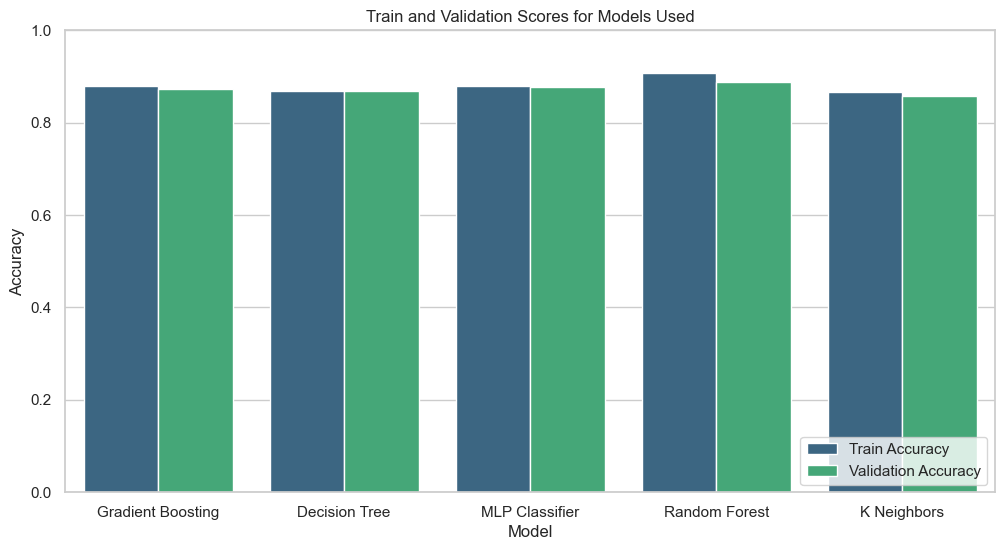

In [26]:
results = pd.DataFrame({
    'Model': ['Gradient Boosting', 'Decision Tree', 'MLP Classifier', 'Random Forest', 'K Neighbors'],
    'Train Accuracy': [GBCmodel.score(X_train, y_train), DTModel.score(X_train, y_train),
                       MLPModel.score(X_train, y_train), RFModel.score(X_train, y_train),
                       KNNModel.score(X_train, y_train)],
    'Validation Accuracy': [GBCmodel.score(X_valid, y_valid), DTModel.score(X_valid, y_valid),
                             MLPModel.score(X_valid, y_valid), RFModel.score(X_valid, y_valid),
                             KNNModel.score(X_valid, y_valid)]
})

results_melted = pd.melt(results, id_vars='Model', var_name='Dataset', value_name='Accuracy')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', hue='Dataset', data=results_melted, palette='viridis')
plt.title('Train and Validation Scores for Models Used')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

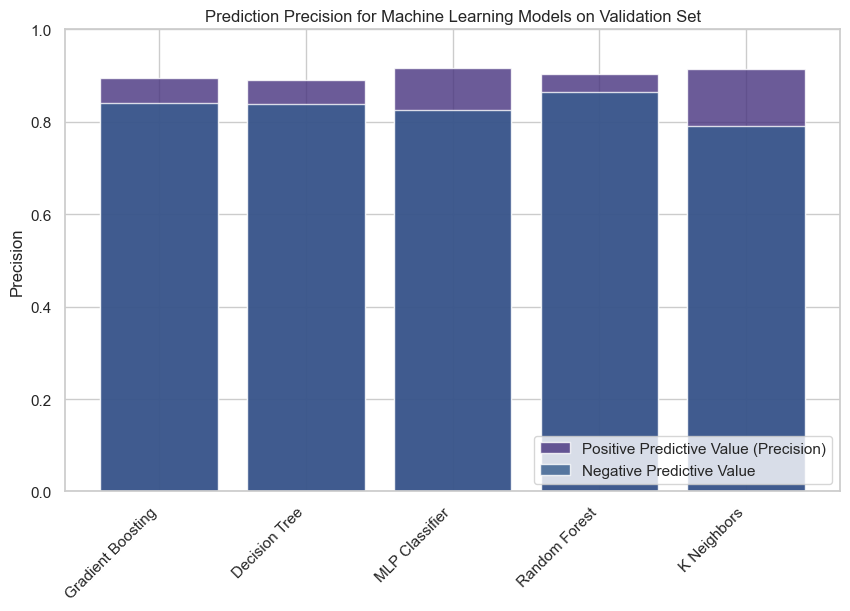

In [27]:
# Function to calculate negative predictive value
def calculate_negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fn)

model_names = ['Gradient Boosting', 'Decision Tree', 'MLP Classifier', 'Random Forest', 'K Neighbors']
precision_positive = [precision_score(y_valid, model.predict(X_valid)) for model in [GBCmodel, DTModel, MLPModel, RFModel, KNNModel]]
precision_negative = [calculate_negative_predictive_value(y_valid, model.predict(X_valid)) for model in [GBCmodel, DTModel, MLPModel, RFModel, KNNModel]]

plt.figure(figsize=(10, 6))
color1 = sns.color_palette('viridis')[0]
color2 = sns.color_palette('viridis')[1]

# Plotting Positive Predictive Value
bars_positive = plt.bar(model_names, precision_positive, color=color1, alpha=0.8, label='Positive Predictive Value (Precision)')

# Plotting Negative Predictive Value
bars_negative = plt.bar(model_names, precision_negative, color=color2, alpha=0.8, label='Negative Predictive Value')

plt.ylabel('Precision')
plt.title('Prediction Precision for Machine Learning Models on Validation Set')
plt.legend(loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.show()
